# Stack Compass — Análisis narrado

**Pregunta:** ¿Qué stacks tecnológicos maximizan el trinomio salario / satisfacción / empleabilidad para un perfil data-IA junior en la UE?

**Fuente:** Stack Overflow Annual Developer Survey (año más reciente disponible).  
**Población:** Roles data/IA (núcleo + frontera) en los 27 países de la UE.

In [1]:
import sys
sys.path.insert(0, "../src")

from load import load_raw, get_duckdb_connection, load_processed
from clean import filter_population, clean_salary, normalize_multi_valued, filter_geography, add_region
from metrics import salary_by_stack, satisfaction_by_stack, employability_by_stack

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Carga de datos

Leemos el CSV crudo sin inferencia de tipos (`low_memory=False`) para evitar advertencias en columnas mixtas.

In [2]:
df_raw = load_raw()
print(f"Filas: {len(df_raw):,}  |  Columnas: {df_raw.shape[1]}")
df_raw.head(2)

Filas: 49,191  |  Columnas: 172


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0


## 2. Limpieza y filtrado de población

Nos quedamos con respondentes en la UE que declaran roles data/IA.  
Después limpiamos la columna salarial eliminando nulos y outliers extremos (p1–p99).

In [3]:
pob = filter_population(df_raw)
pob = filter_geography(pob)
pob = add_region(pob)
print(f"Población filtrada: {len(pob):,} filas")

pob_sal = clean_salary(pob)
print(f"NaN en salario: {pob_sal['ConvertedCompYearly'].isna().sum()}")
print(f"Con salario válido (p1-p99): {len(pob_sal):,} filas")

Población filtrada: 1,194 filas
NaN en salario: 297
Con salario válido (p1-p99): 1,194 filas


In [4]:
pob_sal.to_csv("../data/processed/survey_clean.csv", index=False)
print("CSV limpio guardado en data/processed/survey_clean.csv")

CSV limpio guardado en data/processed/survey_clean.csv


## 3. Métricas del trinomio

Calculamos las tres dimensiones de interés sobre la misma población.

### 3.1 Salario por stack

Mediana de `ConvertedCompYearly` (USD/año) agrupada por tecnología principal.

In [5]:
df_sal = salary_by_stack(pob_sal)
df_sal.head(10)

,Region,tech,median_salary,p25,p75,n
0,España,TypeScript,73669.0,58007.0,87011.0,17
1,España,Bash/Shell (all shells),69609.0,45043.0,84691.0,35
2,España,Python,69029.0,46449.5,84111.0,56
3,España,SQL,65548.0,48871.0,81210.0,38
4,España,HTML/CSS,63808.0,41765.0,81210.0,25
5,España,JavaScript,58007.0,35268.5,81210.0,23
6,UE sin España,MicroPython,87011.0,53366.5,104413.0,15
7,UE sin España,Groovy,83531.0,58007.0,109866.0,69
8,UE sin España,MATLAB,81088.0,54817.0,102188.5,26
9,UE sin España,TypeScript,80050.0,55687.0,108621.5,230


### 3.2 Satisfacción por stack

Puntuación media de `JobSat` por tecnología. Escala ordinal de la encuesta.

In [6]:
df_sat = satisfaction_by_stack(pob)
df_sat.head(10)

,Region,tech,mean_jobsat,n
0,España,HTML/CSS,7.750000,24
1,España,TypeScript,7.578947,19
2,España,JavaScript,7.318182,22
3,España,Python,7.153846,52
4,España,SQL,7.081081,37
5,España,Bash/Shell (all shells),7.000000,32
6,UE sin España,MATLAB,7.823529,17
7,UE sin España,Kotlin,7.420000,50
8,UE sin España,Lua,7.417722,79
9,UE sin España,GDScript,7.380952,21


### 3.3 Empleabilidad por stack

Frecuencia de aparición en `LanguageHaveWorkedWith` dentro de la población filtrada.  
Mayor frecuencia → más posiciones que demandan ese stack.

In [7]:
df_emp = employability_by_stack(pob)
df_emp.head(20)

,tech,Region,n,rank
0,Python,España,66,1
1,SQL,España,45,2
2,Bash/Shell (all shells),España,40,3
3,HTML/CSS,España,30,4
4,JavaScript,España,27,5
5,TypeScript,España,20,6
6,Python,UE sin España,860,1
7,Bash/Shell (all shells),UE sin España,648,2
8,SQL,UE sin España,628,3
9,JavaScript,UE sin España,459,4


## 4. Conclusiones

> *Sección pendiente de rellenar una vez las métricas estén implementadas.*

## 5. Visualización

> *Sección pendiente de rellenar una vez las métricas estén implementadas.*

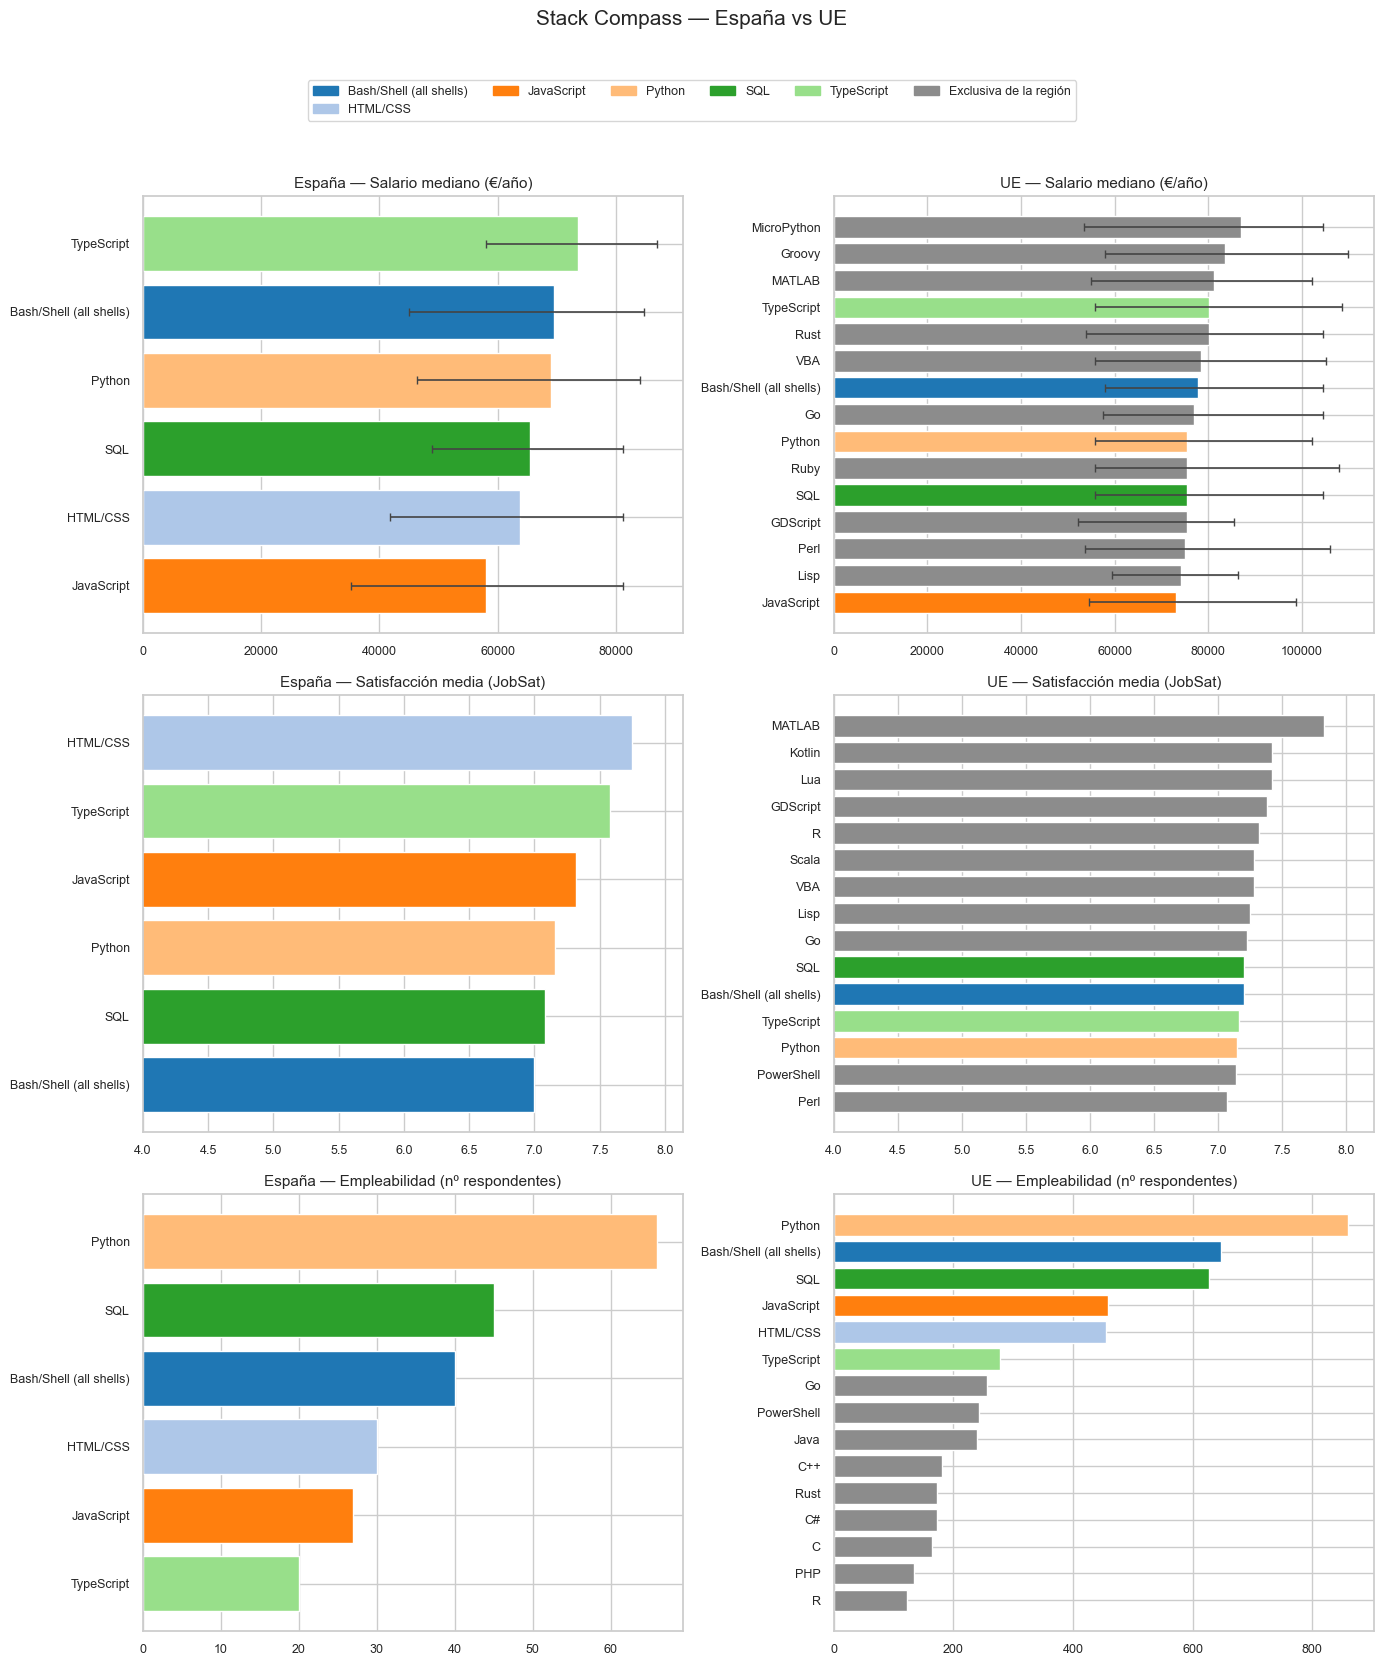

In [8]:
import matplotlib.pyplot as plt
from metrics import salary_by_stack, satisfaction_by_stack, employability_by_stack
from visualization import build_dashboard

# 1. pipeline de limpieza (tu df ya filtrado y con Region)
#    asumiendo que 'df' es el resultado de filter_population -> filter_geography -> add_region -> clean_salary

# 2. ejecutar las tres queries
#df_salary = salary_by_stack(df)
#df_sat = satisfaction_by_stack(df)
#df_emp = employability_by_stack(df)

# 3. construir y mostrar
fig = build_dashboard(df_sal, df_sat, df_emp)
plt.show()